# Кластеризация анекдотов anekdot.ru

Этот ноутбук повторяет логику старого `Sophie_анеки_кластеризация.ipynb`,
но на финальном корпусе и финальных артефактах дипломной работы.

Внутри есть не только итоговые метрики, но и ход работы: загрузка
данных, проверка эмбеддингов, анализ близости текстов, сравнение
простых кластерных подходов, Leiden + UMAP, сохранение таблицы с
кластерами и дополнительные контрольные оценки.

Главный результат остается кластеризацией без учителя. Теги не
добавляются в текст и не используются как признаки основной модели.


In [1]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import IFrame, Markdown, display
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

rng = np.random.default_rng(42)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 140)
plt.rcParams["figure.dpi"] = 120
print(f"Рабочая папка: {ROOT}")


Рабочая папка: C:\Users\user\Учёба\4 курс\Диплом Сони


## Воспроизводимый запуск

По умолчанию ноутбук читает уже сохраненные артефакты, чтобы его
можно было быстро открыть и показать научному руководителю. Если
нужно пересобрать все легкие этапы, включите `RUN_PIPELINE = True`.

Шаг с BGE-M3 эмбеддингами тяжелый и обычно запускается отдельно на
GPU. В этом ноутбуке он не пересчитывается автоматически.


In [2]:
RUN_PIPELINE = False
RUN_AUXILIARY_CONTROLS = False

commands = [
    [sys.executable, "scripts/run_all.py", "--skip-existing"],
]
auxiliary_commands = [
    [sys.executable, "scripts/13_hierarchical_evaluation.py"],
    [sys.executable, "scripts/14_supervised_tag_prediction_baseline.py"],
    [sys.executable, "scripts/15_semi_supervised_upper_bound.py"],
    [sys.executable, "scripts/16_final_evaluation_story.py"],
]

if RUN_AUXILIARY_CONTROLS:
    commands.extend(auxiliary_commands)

for cmd in commands:
    print(" ".join(cmd))
    if RUN_PIPELINE:
        subprocess.run(cmd, cwd=ROOT, check=True)


C:\Users\user\AppData\Local\Programs\Python\Python311\python.exe scripts/run_all.py --skip-existing


## Загрузка корпуса

Финальная выборка отличается от старого `anekdots.csv`: здесь
оставлены только анекдоты, у которых на сайте есть хотя бы один тег.
Это нужно для внешней проверки кластеров без ручной построчной
разметки.


In [3]:
dataset = pd.read_csv(ROOT / "data/processed/anekdots_tagged.csv")
clustered = pd.read_csv(ROOT / "data/processed/anekdots_tagged_clustered.csv")
periods = pd.PeriodIndex(
    year=dataset["year"].astype(int),
    month=dataset["month"].astype(int),
    freq="M",
)

print(f"Строк в корпусе: {len(dataset):,}".replace(",", " "))
print(f"Строк с тегами: {(dataset['tag_count'] >= 1).sum():,}".replace(",", " "))
print(f"Период: {periods.min()} ... {periods.max()}")
print(f"Месяцев с данными: {dataset[['year', 'month']].drop_duplicates().shape[0]}")
print(f"Финальных кластеров: {clustered['cluster_final'].nunique()}")

display(dataset[["id", "year", "month", "text_clean", "tags_raw", "macro_tags"]].head(5))


Строк в корпусе: 5 509
Строк с тегами: 5 509
Период: 1996-01 ... 2026-03
Месяцев с данными: 356
Финальных кластеров: 20


,id,year,month,text_clean,tags_raw,macro_tags
0,-413100001,1996,1,"Лежит Пятачок, без глаза и без ноги . Походит Иа-Иа и спрашивает: - Что случилось , Пятачок ? - Да вот, поспорили с Винни на глаз, что о...","[""Винни-Пух""]","[""literature_folklore_characters""]"
1,-413100002,1996,1,Наркоман поступил на работу в зоопарк. На следующий день ему поручили убрать клетку с черепахами. Вечером работники собираются в раздева...,"[""наркотики""]","[""alcohol_smoking_drugs""]"
2,-413000002,1996,1,"В троллейбус входит мужик с боксером(кобель). Малой лет четырех, указывая на собаку: - Мама, смотри какие шарики!","[""троллейбус""]","[""transport""]"
3,-413000003,1996,1,"Троллейбус. Утро. Батя, молоденький старлей, распекает ноющего сына. - Будешь хныкать - всем в детсадике расскажу что ты нытик, прям как...","[""троллейбус""]","[""transport""]"
4,-412800006,1996,1,"У одного мужика небыло чувства юмора, ну абсолютно. И родственники решили у него это чувство развить и собравшись стали рассказывать ане...","[""юмор""]","[""absurd_philosophy""]"


## Небольшой разведочный анализ

Сначала посмотрим, насколько равномерно корпус покрывает годы и
какие макро-теги встречаются чаще всего. Макро-теги дальше
используются только для оценки и интерпретации, не для обучения
основной кластеризации.


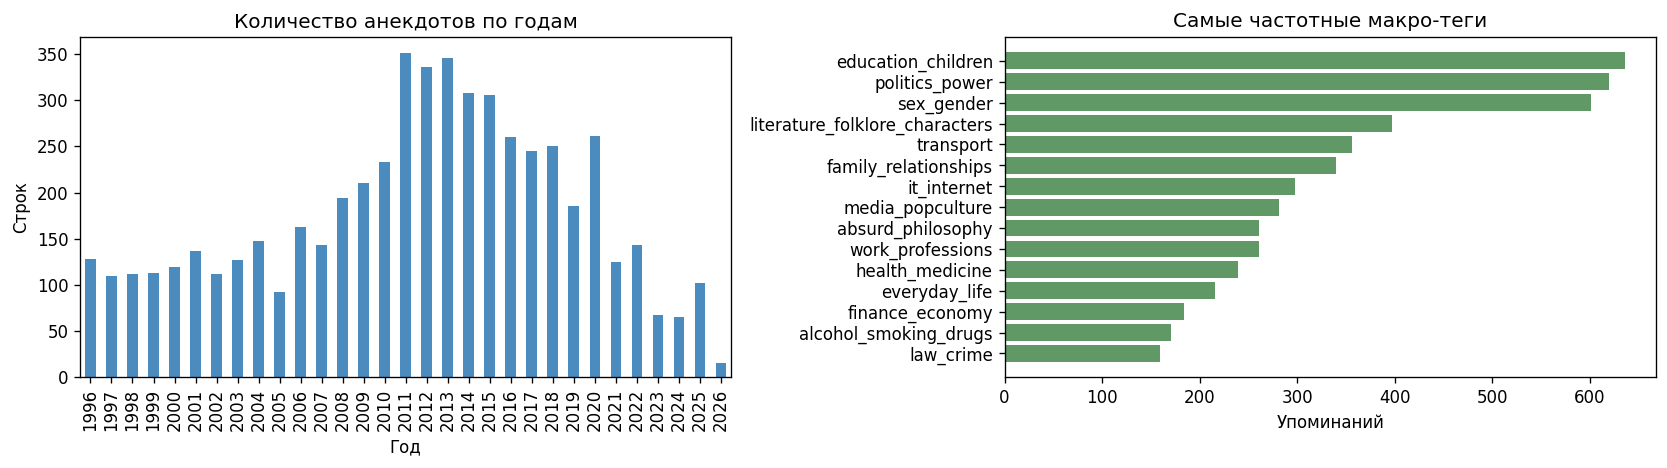

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

dataset["year"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#4b8bbe")
axes[0].set_title("Количество анекдотов по годам")
axes[0].set_xlabel("Год")
axes[0].set_ylabel("Строк")
axes[0].tick_params(axis="x", labelrotation=90)

top_macro = pd.read_csv(ROOT / "outputs/tables/top_macro_tags.csv").head(15)
axes[1].barh(top_macro["macro_tag"][::-1], top_macro["count"][::-1], color="#609966")
axes[1].set_title("Самые частотные макро-теги")
axes[1].set_xlabel("Упоминаний")

fig.tight_layout()
plt.show()


## Получение эмбеддингов

В старом ноутбуке эмбеддинги считались прямо в ячейке. В финальной
версии они уже сохранены как артефакты, чтобы не тратить время и
GPU-кредиты при каждом показе. Используется модель `BAAI/bge-m3`.

Исторически сравнивались несколько моделей:

- `sentence-transformers/sentence-t5-base`
- `intfloat/multilingual-e5-base`
- `intfloat/multilingual-e5-large`
- `BAAI/bge-m3`

Для финального пайплайна оставлена `BAAI/bge-m3`, потому что она
лучше подошла для русскоязычных коротких текстов и дала более
пригодное пространство соседства.


In [5]:
embeddings = np.load(ROOT / "data/embeddings/tagged_bge_m3.npy")
pca128 = np.load(ROOT / "data/embeddings/tagged_pca128.npy")
ids = np.load(ROOT / "data/embeddings/tagged_ids.npy", allow_pickle=True)
manifest = json.loads((ROOT / "data/embeddings/tagged_embeddings_manifest.json").read_text(encoding="utf-8"))

print("Модель:", manifest["model_id"])
print("Устройство при расчете:", manifest["device"])
print("Время расчета, секунд:", manifest["runtime_seconds"])
print("Форма эмбеддингов:", embeddings.shape)
print("Форма PCA:", pca128.shape)
print("Доля объясненной дисперсии PCA:", round(manifest["pca_explained_variance_ratio_sum"], 4))
print("Обрезанных текстов токенизатором:", manifest["truncated_text_count"])
print("ID синхронизированы с датасетом:", bool((ids.astype(str) == dataset["id"].astype(str).to_numpy()).all()))


Модель: BAAI/bge-m3
Устройство при расчете: cuda:0
Время расчета, секунд: 124.072
Форма эмбеддингов: (5509, 1024)
Форма PCA: (5509, 128)
Доля объясненной дисперсии PCA: 0.6721
Обрезанных текстов токенизатором: 0
ID синхронизированы с датасетом: True


## Проверка синхронизации

Это аналог `sanity_check` из старого ноутбука. Проверяем, что строки
корпуса, эмбеддинги, PCA, UMAP и финальные метки кластеров
согласованы между собой.


In [6]:
def sanity_check(df, clustered_df, embeddings_matrix, pca_matrix, ids_array):
    print("\n=== SANITY CHECK ===")
    print("dataset rows:", len(df))
    print("clustered rows:", len(clustered_df))
    print("embeddings rows:", embeddings_matrix.shape[0])
    print("pca rows:", pca_matrix.shape[0])
    print("unique final clusters:", clustered_df["cluster_final"].nunique())
    print("largest cluster share:", round(clustered_df["cluster_final"].value_counts(normalize=True).max(), 4))
    print("missing texts:", int(df["text_clean"].isna().sum()))
    print("missing UMAP coordinates:", int(clustered_df[["umap2_x", "umap2_y", "umap3_x", "umap3_y", "umap3_z"]].isna().sum().sum()))

    assert len(df) == len(clustered_df) == embeddings_matrix.shape[0] == pca_matrix.shape[0] == len(ids_array)
    assert (ids_array.astype(str) == df["id"].astype(str).to_numpy()).all()
    assert clustered_df["cluster_final"].nunique() == 20
    assert clustered_df["feature_set"].nunique() == 1
    print("OK: данные согласованы")

sanity_check(dataset, clustered, embeddings, pca128, ids)



=== SANITY CHECK ===
dataset rows: 5509
clustered rows: 5509
embeddings rows: 5509
pca rows: 5509
unique final clusters: 20
largest cluster share: 0.1291
missing texts: 0
missing UMAP coordinates: 0
OK: данные согласованы


## Анализ пространства эмбеддингов

Как и в старом ноутбуке, сравним косинусное сходство случайных пар
и ближайших соседей. Если ближайшие соседи заметно ближе случайных
пар, значит в эмбеддингах есть полезная структура соседства.


In [7]:
emb_norm = normalize(embeddings, norm="l2")
n_pairs = 20_000
a = rng.integers(0, len(emb_norm), size=n_pairs)
b = rng.integers(0, len(emb_norm), size=n_pairs)
keep = a != b
a, b = a[keep], b[keep]
random_sims = np.sum(emb_norm[a] * emb_norm[b], axis=1)

nn = NearestNeighbors(n_neighbors=2, metric="cosine")
nn.fit(emb_norm)
nn_dist, nn_idx = nn.kneighbors(emb_norm)
nearest_sims = 1 - nn_dist[:, 1]

sim_summary = pd.DataFrame(
    {
        "random_pairs": pd.Series(random_sims).describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]),
        "nearest_neighbors": pd.Series(nearest_sims).describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]),
    }
)
display(sim_summary)
print("Разница средних nearest - random:", round(float(nearest_sims.mean() - random_sims.mean()), 4))


,random_pairs,nearest_neighbors
count,19997.000000,5509.000000
mean,0.390425,0.631842
std,0.069463,0.061647
min,0.107208,0.452306
5%,0.282323,0.541777
25%,0.342384,0.589978
50%,0.387200,0.626728
75%,0.434083,0.668943
95%,0.509596,0.734130
max,0.708168,0.994206


Разница средних nearest - random: 0.2414


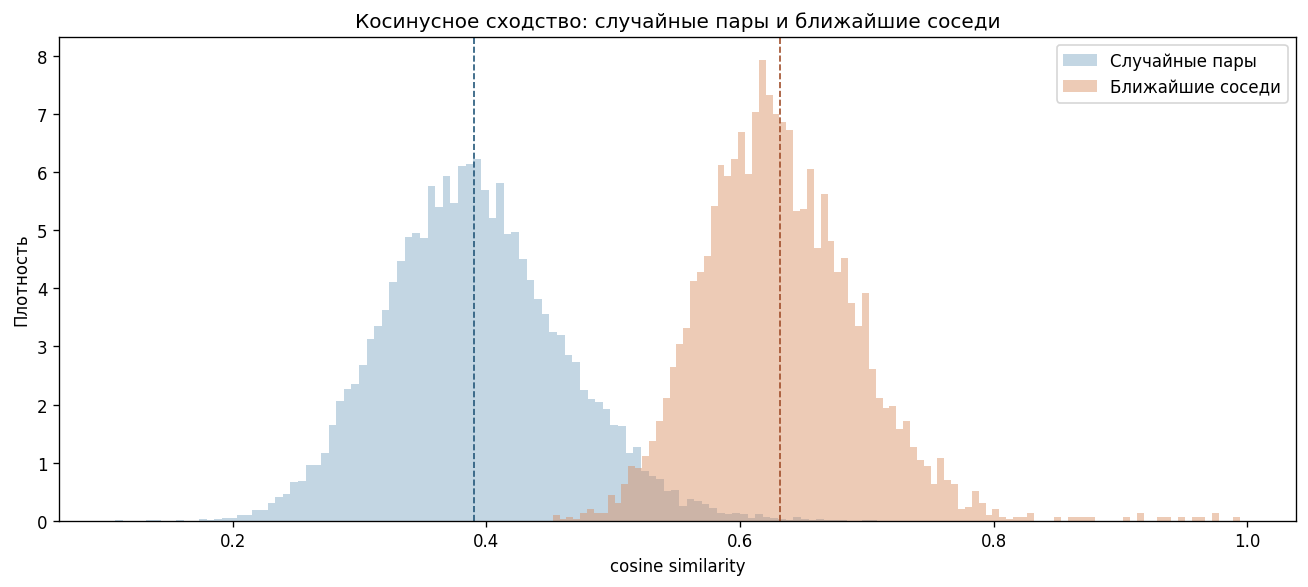

In [8]:
plt.figure(figsize=(11, 5))
plt.hist(random_sims, bins=100, density=True, alpha=0.45, label="Случайные пары", color="#7aa6c2")
plt.hist(nearest_sims, bins=100, density=True, alpha=0.45, label="Ближайшие соседи", color="#d98c5f")
plt.axvline(random_sims.mean(), color="#24577a", linestyle="--", linewidth=1)
plt.axvline(nearest_sims.mean(), color="#a14f2b", linestyle="--", linewidth=1)
plt.title("Косинусное сходство: случайные пары и ближайшие соседи")
plt.xlabel("cosine similarity")
plt.ylabel("Плотность")
plt.legend()
plt.tight_layout()
plt.show()


## Почему не простой KMeans

Старый ноутбук проверял KMeans и показывал, что для такого
пространства он работает хуже. В финальном пайплайне это сохранено
как сравнение моделей: KMeans и агломеративная кластеризация есть в
таблице, но главным результатом выбран Leiden.


In [9]:
metrics = pd.read_csv(ROOT / "outputs/tables/final_metrics_summary.csv")
comparison = (
    metrics[metrics["subset"].eq("all")]
    .loc[:, ["model", "method", "feature_set", "params", "cluster_count", "largest_cluster_share", "ari", "ami", "v_measure", "pairwise_f1"]]
    .sort_values(["model"])
)
display(comparison)


,model,method,feature_set,params,cluster_count,largest_cluster_share,ari,ami,v_measure,pairwise_f1
9,cluster_agglomerative_best,agglomerative,dense_bge_pca,n_clusters=25;linkage=average,25,0.173534,0.168063,0.282489,0.297141,0.243238
6,cluster_kmeans_best,kmeans,hybrid_dense_lexical_dw0.75_lw0.25,n_clusters=25,25,0.060083,0.178158,0.300049,0.313457,0.224658
3,cluster_leiden_tuned,leiden,hybrid_dense_lexical_dw0.75_lw0.25,k=75;resolution=2.0;seed=7,20,0.129062,0.276840,0.377156,0.387097,0.338826
12,final,leiden,hybrid_dense_lexical_dw0.75_lw0.25,k=75;resolution=2.0;seed=7,20,0.129062,0.276840,0.377156,0.387097,0.338826
0,old_leiden,leiden,dense_bge_pca,k=30;resolution=1.0;seed=42,12,0.204574,0.196673,0.303855,0.310895,0.284616


## Теперь кластеризуем графом: Leiden + UMAP

Кластеризация выполняется не в координатах UMAP. UMAP нужен только
для визуального отображения уже найденных кластеров. Основная
финальная конфигурация:

- признаки: `hybrid_dense_lexical_dw0.75_lw0.25`
- метод: Leiden
- `k=75`, `resolution=2.0`, `seed=7`
- число кластеров: 20


In [10]:
final_main = metrics[(metrics["model"] == "final") & (metrics["subset"] == "all")].iloc[0]
display(pd.DataFrame([final_main])[[
    "method", "feature_set", "params", "rows", "cluster_count",
    "largest_cluster_share", "ari", "ami", "v_measure",
    "pairwise_precision", "pairwise_recall", "pairwise_f1"
]])


,method,feature_set,params,rows,cluster_count,largest_cluster_share,ari,ami,v_measure,pairwise_precision,pairwise_recall,pairwise_f1
12,leiden,hybrid_dense_lexical_dw0.75_lw0.25,k=75;resolution=2.0;seed=7,5509,20,0.129062,0.27684,0.377156,0.387097,0.351852,0.326731,0.338826


In [11]:
demo_export = ROOT / "outputs/tables/clustered_anekdots_for_supervisor.csv"
export_columns = [
    "id", "year", "month", "text_clean", "tags_raw", "macro_tags",
    "cluster_final", "cluster_method", "feature_set",
    "umap2_x", "umap2_y", "umap3_x", "umap3_y", "umap3_z",
]
clustered[export_columns].to_csv(demo_export, index=False, encoding="utf-8", lineterminator="\n")
print(f"Saved: {demo_export.relative_to(ROOT)}")


Saved: outputs\tables\clustered_anekdots_for_supervisor.csv


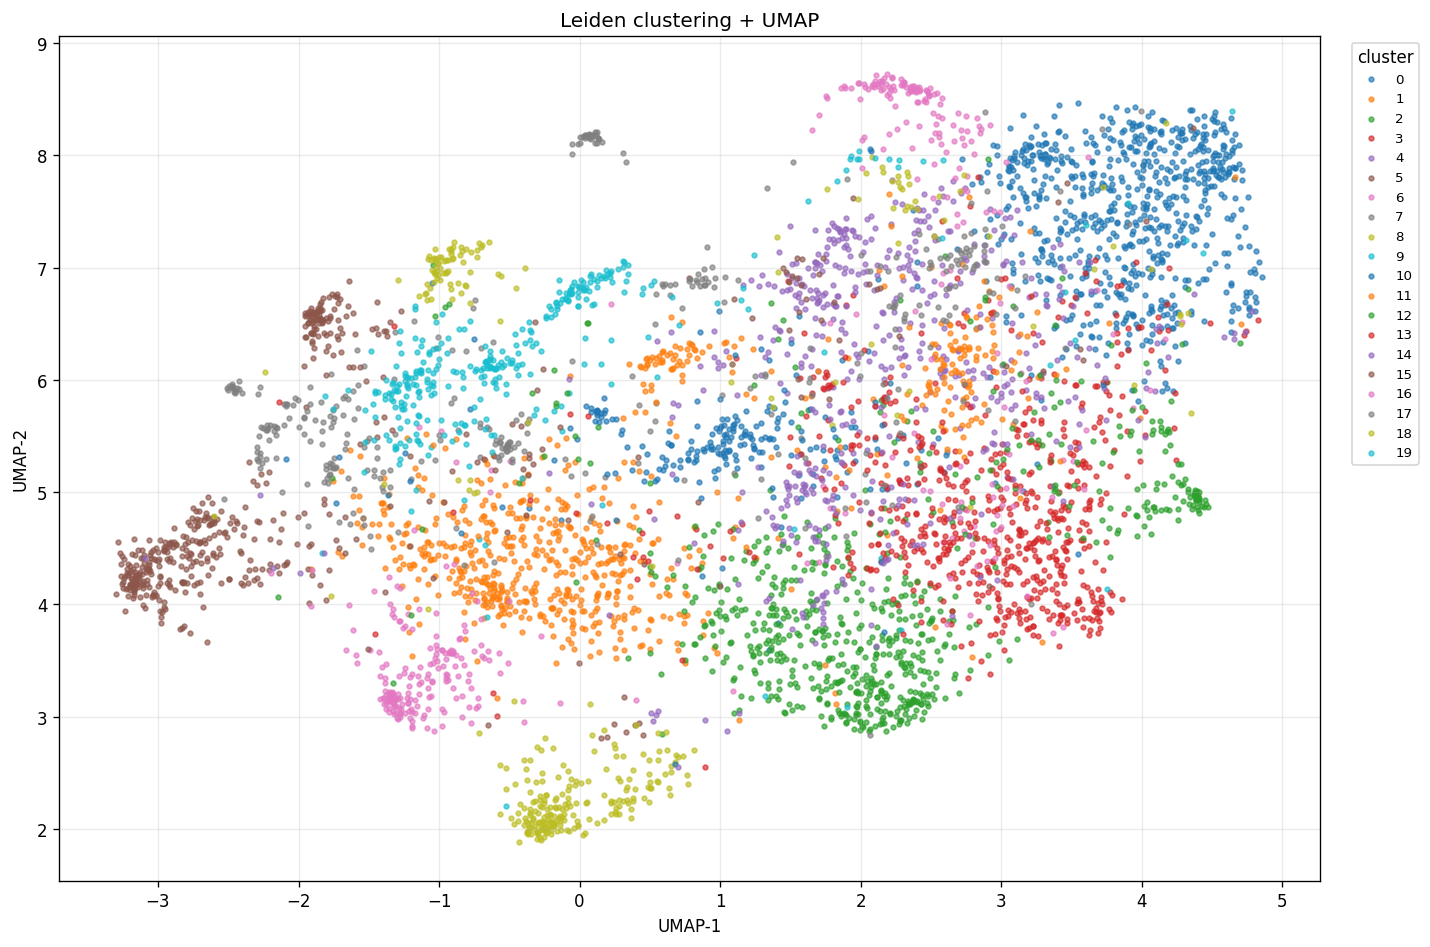

In [12]:
plt.figure(figsize=(12, 8))
labels = clustered["cluster_final"].astype(str)
for label in sorted(labels.unique(), key=lambda x: int(x)):
    part = clustered[labels == label]
    plt.scatter(part["umap2_x"], part["umap2_y"], s=8, alpha=0.65, label=label)

plt.title("Leiden clustering + UMAP")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.grid(alpha=0.25)
plt.legend(title="cluster", bbox_to_anchor=(1.02, 1), loc="upper left", ncol=1, fontsize=8)
plt.tight_layout()
plt.show()


## Интерактивная 3D-карта

Эта карта удобна для демонстрации: можно вращать пространство и
смотреть отдельные точки. Если в просмотрщике HTML не отобразится,
откройте файл `outputs/figures/umap3d_final.html`.


In [13]:
html_path = ROOT / "outputs/figures/umap3d_final.html"
display(IFrame(src=str(html_path), width="100%", height=620))


## Интерпретация кластеров

Для отчета важны не только номера кластеров, но и их содержательное
описание. Ниже показаны размеры кластеров и готовые карточки
интерпретации.


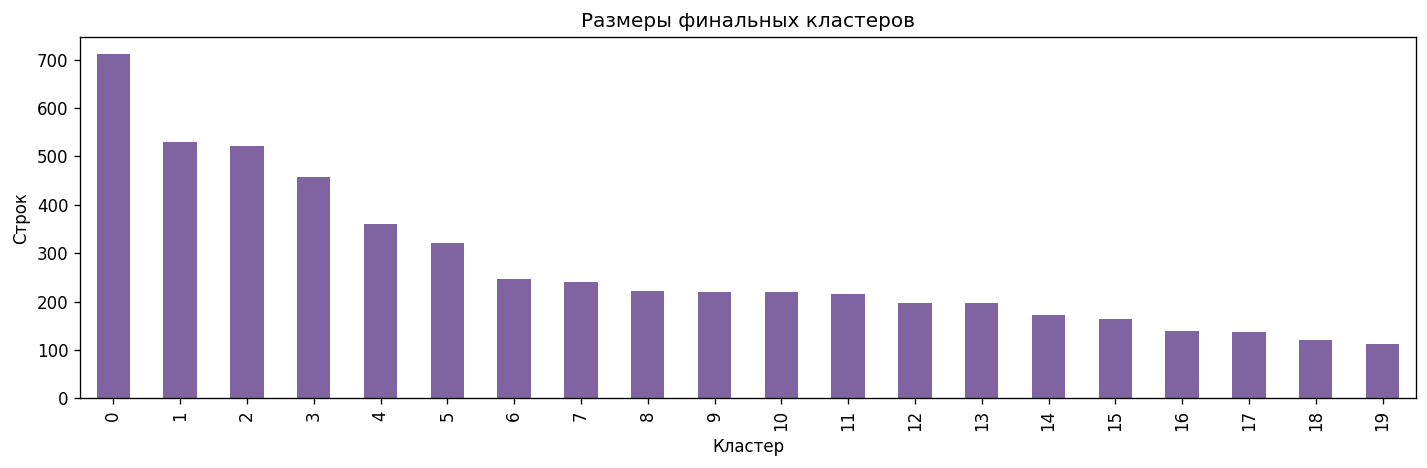

,cluster_final,size,share,suggested_name,top_macro_tags,top_raw_tags,top_ctfidf_terms,year_min,year_max,central_example_id,central_example_preview
0,0,711,0.129062,politics_power | finance_economy | health_medicine | media_popculture,politics_power | finance_economy | health_medicine | media_popculture,Путин | политика | Украина | Медведев | коррупция,путин | владимир | путина | владимирович | украины | президента | сша | президент,1996,2026,853356,"То, что Порошенко поднялся в рейтинге богатейших украинцев на 4-е место, - это элемент гибридной войны России по дискредитации президент..."
1,1,530,0.096206,family_relationships | sex_gender | work_professions | it_internet,family_relationships | sex_gender | work_professions | it_internet,муж и жена | девушки | мужчины | работа | секс,жена | муж | мужу | дорогая | девушка | жене | люся | дорогой,1996,2026,817881,"Жена мужу: - Ты работу любишь больше, чем меня! - С чего ты взяла? - У тебя вечером, перед сексом со мной, ТАК не стоит, как утром перед..."
2,2,522,0.094754,sex_gender | family_relationships | it_internet | media_popculture,sex_gender | family_relationships | it_internet | media_popculture,девушки | муж и жена | мужчины | секс | любовь,женщины | женщина | мужчина | девушки | жена | девушка | мужчины | муж,1998,2025,672713,"С женским телом всегда легче договориться, чем с самой женщиной."
3,3,457,0.082955,absurd_philosophy | work_professions | finance_economy | it_internet,absurd_philosophy | work_professions | finance_economy | it_internet,о жизни | работа | интернет | деньги | политика,деньги | работе | жизни | тюрьме | отпуск | хорошо | отдыхать | те,1997,2026,242342,"Работать надо так, чтобы не было мучительно больно за бесплатно потраченное время."
4,4,361,0.065529,transport | consumer_services | cities_places | it_internet,transport | consumer_services | cities_places | it_internet,авто | объявления | реклама | гаи | Москва,объявление | гибдд | тариф | москве | курицы | дорогу | бесплатно | реклама,1996,2026,522591,"Омский шинный завод выиграл тендер на поставку автошин для ""Формулы 1"" в количестве 2000 штук... для ограждения трассы."
5,5,320,0.058087,education_children | politics_power | family_relationships | literature_folklore_characters,education_children | politics_power | family_relationships | literature_folklore_characters,вовочка | школа | дети | студент | русский язык,учительница | папа | мама | школе | уроке | урок | спрашивает | дети,1996,2026,13722,"Сидят Вовочка с Машенькой на уроке и балаболят. Машенька: - Вот горе у меня, залетела, а от кого - не знаю! Вовочка: - Это фигня. Вот я ..."
6,6,247,0.044836,health_medicine | sex_gender | alcohol_smoking_drugs | education_children,health_medicine | sex_gender | alcohol_smoking_drugs | education_children,врачи | аптека | коронавирус | мужчины | муж и жена,доктор | врач | врачу | приходит | аптеке | ему | аптеку | больной,1996,2025,300741,"Зубной врач после проведенного лечения смущенно говорит пациенту: - Простите ради бога, но я, похоже, удалил вам здоровый зуб. Теперь пр..."
7,7,241,0.043747,literature_folklore_characters | everyday_life | sex_gender | animals,literature_folklore_characters | everyday_life | sex_gender | animals,Ржевский | чапаев | Винни-Пух | Иван-царевич | золотая рыбка,поручик | ржевский | петька | винни | волк | василий | пятачок | ему,1996,2025,-10018590,"Идет Иван-Царевич по лесу. Вдруг видит - в траве мышка сидит. Кинулся он к ней, хотел уже раздавить, как мышка говорит ему человеческим ..."
8,8,222,0.040298,education_children | army_police | sex_gender | work_professions,education_children | army_police | sex_gender | work_professions,студент | школа | армия | работа | девушки,студент | профессор | экзамен | студента | препод | студенты | экзамене | преподаватель,1996,2025,15595,"Пpиходит студент на экзамен по устpойству чего-то. Взял билет, подготовился, поpа отвечать. Подходит он к пpеподу: - Извините, так и так..."
9,9,220,0.039935,transport | cities_places | ethnic_regional

In [14]:
sizes = pd.read_csv(ROOT / "outputs/tables/cluster_final_sizes.csv")
cards = pd.read_csv(ROOT / "outputs/tables/cluster_final_interpretation_cards.csv")

fig, ax = plt.subplots(figsize=(12, 4))
sizes.sort_values("size", ascending=False).plot(
    x="cluster_final", y="size", kind="bar", legend=False, color="#8064a2", ax=ax
)
ax.set_title("Размеры финальных кластеров")
ax.set_xlabel("Кластер")
ax.set_ylabel("Строк")
plt.tight_layout()
plt.show()

display(cards.head(12))


## Иерархическая оценка

Подробные макро-теги дополнительно объединены в широкие группы.
Обычно такая оценка может быть выше, потому что она проверяет более
грубое тематическое совпадение. В текущем прогоне она не стала выше
для V-measure и pairwise F1: широкие группы оказались достаточно
разнородными, поэтому это только вспомогательная проверка.


In [15]:
hierarchical = pd.read_csv(ROOT / "outputs/tables/hierarchical_metrics_summary.csv")
display(hierarchical[[
    "label_level", "subset", "rows", "label_count", "ari", "ami",
    "nmi", "homogeneity", "completeness", "v_measure", "pairwise_f1"
]])


,label_level,subset,rows,label_count,ari,ami,nmi,homogeneity,completeness,v_measure,pairwise_f1
0,level_1_broad,all,5509,7,0.169699,0.268966,0.272183,0.342003,0.226037,0.272183,0.247747
1,level_1_broad,single_clear_label,4993,7,0.188140,0.293314,0.296760,0.374484,0.245755,0.296760,0.264971
2,level_2_detailed,all,5509,27,0.276840,0.377156,0.387097,0.375376,0.399574,0.387097,0.338826
3,level_2_detailed,single_clear_label,4921,27,0.310480,0.409100,0.419784,0.408894,0.431270,0.419784,0.354086


## Контрольная модель с учителем

Это не кластеризация. Здесь модель учится предсказывать макро-теги
по текстовым признакам на разбиении train/validation/test. Такой
baseline показывает, что теговый сигнал в тексте есть, но его нельзя
выдавать за независимую оценку кластеризации.


In [16]:
supervised = pd.read_csv(ROOT / "outputs/tables/supervised_tag_prediction_baseline.csv")
supervised_test = supervised[supervised["split"] == "test"].sort_values("micro_f1", ascending=False)
display(supervised_test[[
    "feature_set", "macro_f1", "micro_f1", "weighted_f1",
    "micro_precision", "micro_recall", "subset_accuracy"
]])


,feature_set,macro_f1,micro_f1,weighted_f1,micro_precision,micro_recall,subset_accuracy
0,hybrid_word_char_bge_pca,0.666485,0.725926,0.718051,0.751179,0.702315,0.672310
1,bge_pca128,0.608953,0.661756,0.654560,0.680653,0.643881,0.600967
2,tfidf_char_wb_3_5,0.576898,0.650144,0.638440,0.681159,0.621830,0.609432
3,tfidf_word_1_2,0.417648,0.536332,0.503704,0.562273,0.512679,0.498186


## Полуобучаемая верхняя граница

В этом эксперименте теги уже влияют на представление текстов:
создаются положительные и отрицательные пары, затем обучается
контрастивное преобразование эмбеддингов. Поэтому это верхняя
граница с подсказкой от тегов, а не независимая проверка.


In [17]:
semi = pd.read_csv(ROOT / "outputs/tables/semi_supervised_embedding_metrics.csv")
display(semi[semi["selected"] == True][[
    "split", "params", "rows", "cluster_count", "ari", "ami",
    "v_measure", "pairwise_precision", "pairwise_recall", "pairwise_f1"
]])


,split,params,rows,cluster_count,ari,ami,v_measure,pairwise_precision,pairwise_recall,pairwise_f1
0,validation_selection,k=30;resolution=2.0;seed=42,1102,16,0.405547,0.427506,0.465997,0.442087,0.484783,0.462452
9,holdout,k=30;resolution=2.0;seed=42,1102,16,0.350148,0.389967,0.430929,0.401860,0.427146,0.414117
10,full_corpus_label_guided,k=30;resolution=2.0;seed=42,5509,16,0.402984,0.426672,0.434081,0.449204,0.478483,0.463381


## Итоговая картина метрик

Основной строкой для диплома остается `unsupervised_leiden_final`.
Остальные строки нужны как поясняющие контрольные эксперименты.


In [18]:
story = pd.read_csv(ROOT / "outputs/tables/final_evaluation_story.csv")
display(story[[
    "display_name", "method_type", "evaluation_scope",
    "main_or_auxiliary", "independent_external_validation",
    "v_measure", "pairwise_f1", "macro_f1", "micro_f1", "note"
]])


,display_name,method_type,evaluation_scope,main_or_auxiliary,independent_external_validation,v_measure,pairwise_f1,macro_f1,micro_f1,note
0,Unsupervised Leiden final,unsupervised_clustering,"full corpus, level-2 detailed macro-tags",main,True,0.387097,0.338826,NaN,NaN,Primary result to report.
1,Unsupervised Leiden evaluated at level-1,hierarchical_evaluation,"full corpus, broad level-1 macro-tags",auxiliary,True,0.272183,0.247747,NaN,NaN,"Same clustering, broader evaluation target; not automatically higher."
2,Unsupervised Leiden evaluated at level-2,hierarchical_evaluation,"full corpus, detailed level-2 macro-tags",auxiliary,True,0.387097,0.338826,NaN,NaN,Should match detailed final validation except for hierarchy plumbing.
3,Supervised tag classifier,supervised_multilabel_classification,held-out test split,auxiliary_control,False,NaN,NaN,0.666485,0.725926,Best test feature set: hybrid_word_char_bge_pca. Not clustering.
4,Semi-supervised fine-tuned clustering holdout,semi_supervised_clustering_upper_bound,holdout split,auxiliary_upper_bound,False,0.430929,0.414117,NaN,NaN,Validation labels selected the representation/parameters; not independent.
5,Semi-supervised fine-tuned clustering full corpus,semi_supervised_clustering_upper_bound,"full corpus, label-guided",auxiliary_upper_bound,False,0.434081,0.463381,NaN,NaN,Full-corpus label-guided number for context only.


## Краткий вывод

Финальная Leiden-модель дает 20 кластеров и умеренные, но честные
метрики: ARI около 0.277, V-measure около 0.387, точная pairwise F1
около 0.339. Это ожидаемо для коротких юмористических текстов:
один анекдот часто совмещает несколько тем, а теги сайта являются
шумной внешней разметкой.

Supervised и semi-supervised результаты полезны как контрольные
эксперименты: они показывают, что связь между текстом и тегами есть.
Но они не заменяют основную кластеризацию без учителя.
